# Working on Real Project with Python on 'London Housing Dataset'

## (A part of Big Data Analysis)

----

# LONDON HOUSING DATASET

-----

This dataset is primarily centered around the housing market of London. It contains a lot of additional relevant data:

* Monthly average house prices
* Yearly number of houses sold
* Monthly number of crimes committed

The data used here is from year 1995 to 2019 of each different area.

This data is available as a CSV file, downloaded from Kaggle.

We will analyze this data using the Pandas DataFrame.

Here, random sets of quesitons are given for which we have to find correct results.

This project is for beginners and for those who want to know how we analyze big data with Python.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv('London Housing Data.csv')

In [71]:
df.head(2)

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN


In [72]:
df

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN
2,3/1/1995,city of london,79121,E09000001,14.0,NaN
3,4/1/1995,city of london,77101,E09000001,7.0,NaN
4,5/1/1995,city of london,84409,E09000001,10.0,NaN
...,...,...,...,...,...,...
13544,9/1/2019,england,249942,E92000001,64605.0,NaN
13545,10/1/2019,england,249376,E92000001,68677.0,NaN
13546,11/1/2019,england,248515,E92000001,67814.0,NaN
13547,12/1/2019,england,250410,E92000001,NaN,NaN


In [73]:
df.isnull().sum()

date                0
area                0
average_price       0
code                0
houses_sold        94
no_of_crimes     6110
dtype: int64

In [74]:
df.houses_sold = df.houses_sold.fillna(df.houses_sold.mean())

In [75]:
df.no_of_crimes = df.no_of_crimes.fillna(0)

In [76]:
df

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.000000,0.0
1,2/1/1995,city of london,82203,E09000001,7.000000,0.0
2,3/1/1995,city of london,79121,E09000001,14.000000,0.0
3,4/1/1995,city of london,77101,E09000001,7.000000,0.0
4,5/1/1995,city of london,84409,E09000001,10.000000,0.0
...,...,...,...,...,...,...
13544,9/1/2019,england,249942,E92000001,64605.000000,0.0
13545,10/1/2019,england,249376,E92000001,68677.000000,0.0
13546,11/1/2019,england,248515,E92000001,67814.000000,0.0
13547,12/1/2019,england,250410,E92000001,3893.994129,0.0


 ----

### (A) Convert the Datatype of 'Date' column to Date-Time format.

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  object 
 1   area           13549 non-null  object 
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  object 
 4   houses_sold    13549 non-null  float64
 5   no_of_crimes   13549 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 635.2+ KB


In [78]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

ValueError: time data "1/1/1995" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

### (B.1) Add a new column ''year'' in the dataframe, which contains years only.

In [ ]:
df['year'] = df['date'].dt.year

In [ ]:
df

,date,area,average_price,code,houses_sold,no_of_crimes,year,month
0,1995-01-01,city of london,91449,E09000001,17.000000,0.0,1995,1
1,1995-02-01,city of london,82203,E09000001,7.000000,0.0,1995,2
2,1995-03-01,city of london,79121,E09000001,14.000000,0.0,1995,3
3,1995-04-01,city of london,77101,E09000001,7.000000,0.0,1995,4
4,1995-05-01,city of london,84409,E09000001,10.000000,0.0,1995,5
...,...,...,...,...,...,...,...,...
13544,2019-09-01,england,249942,E92000001,64605.000000,0.0,2019,9
13545,2019-10-01,england,249376,E92000001,68677.000000,0.0,2019,10
13546,2019-11-01,england,248515,E92000001,67814.000000,0.0,2019,11
13547,2019-12-01,england,250410,E92000001,3893.994129,0.0,2019,12


### (B.2) Add a new column ''month'' as 2nd column in the dataframe, which contains month only.

In [ ]:
df['month'] = df.date.dt.month

### (C) Remove the columns 'year' and 'month' from the dataframe.

In [ ]:
df.drop(columns=['year','month'],inplace=True)

In [ ]:
df

,date,area,average_price,code,houses_sold,no_of_crimes,year
0,1995-01-01,city of london,91449,E09000001,17.000000,0.0,1995
1,1995-02-01,city of london,82203,E09000001,7.000000,0.0,1995
2,1995-03-01,city of london,79121,E09000001,14.000000,0.0,1995
3,1995-04-01,city of london,77101,E09000001,7.000000,0.0,1995
4,1995-05-01,city of london,84409,E09000001,10.000000,0.0,1995
...,...,...,...,...,...,...,...
13544,2019-09-01,england,249942,E92000001,64605.000000,0.0,2019
13545,2019-10-01,england,249376,E92000001,68677.000000,0.0,2019
13546,2019-11-01,england,248515,E92000001,67814.000000,0.0,2019
13547,2019-12-01,england,250410,E92000001,3893.994129,0.0,2019


### (D) Show all the records where 'No. of Crimes' is 0. And, how many such records are there ?

In [ ]:
df[df.no_of_crimes == 0.0].no_of_crimes.value_counts()

no_of_crimes
0.0    6214
Name: count, dtype: int64

### (E) What is the maximum & minimum 'average_price' per year in england ?

In [ ]:
df['year'] = df['date'].dt.year

In [80]:
df.average_price.min()

40722

In [81]:
df.average_price.max()

1463378

### (F) What is the Maximum & Minimum No. of Crimes recorded per area ?

In [84]:
df.groupby('area').no_of_crimes.min()

area
barking and dagenham      0.0
barnet                    0.0
bexley                    0.0
brent                     0.0
bromley                   0.0
camden                    0.0
city of london            0.0
croydon                   0.0
ealing                    0.0
east midlands             0.0
east of england           0.0
enfield                   0.0
england                   0.0
greenwich                 0.0
hackney                   0.0
hammersmith and fulham    0.0
haringey                  0.0
harrow                    0.0
havering                  0.0
hillingdon                0.0
hounslow                  0.0
inner london              0.0
islington                 0.0
kensington and chelsea    0.0
kingston upon thames      0.0
lambeth                   0.0
lewisham                  0.0
london                    0.0
merton                    0.0
newham                    0.0
north east                0.0
north west                0.0
outer london              0.0
redbr

In [86]:
df.groupby('area').no_of_crimes.max()

area
barking and dagenham      2049.0
barnet                    2893.0
bexley                    1914.0
brent                     2937.0
bromley                   2637.0
camden                    4558.0
city of london              10.0
croydon                   3263.0
ealing                    3401.0
east midlands                0.0
east of england              0.0
enfield                   2798.0
england                      0.0
greenwich                 2853.0
hackney                   3466.0
hammersmith and fulham    2645.0
haringey                  3199.0
harrow                    1763.0
havering                  1956.0
hillingdon                2819.0
hounslow                  2817.0
inner london                 0.0
islington                 3384.0
kensington and chelsea    2778.0
kingston upon thames      1379.0
lambeth                   4701.0
lewisham                  2813.0
london                       0.0
merton                    1623.0
newham                    3668.0
north

### (G) Show the total count of records of each area, where average price is less than 100000.

In [87]:
df.head()

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,0.0
1,2/1/1995,city of london,82203,E09000001,7.0,0.0
2,3/1/1995,city of london,79121,E09000001,14.0,0.0
3,4/1/1995,city of london,77101,E09000001,7.0,0.0
4,5/1/1995,city of london,84409,E09000001,10.0,0.0


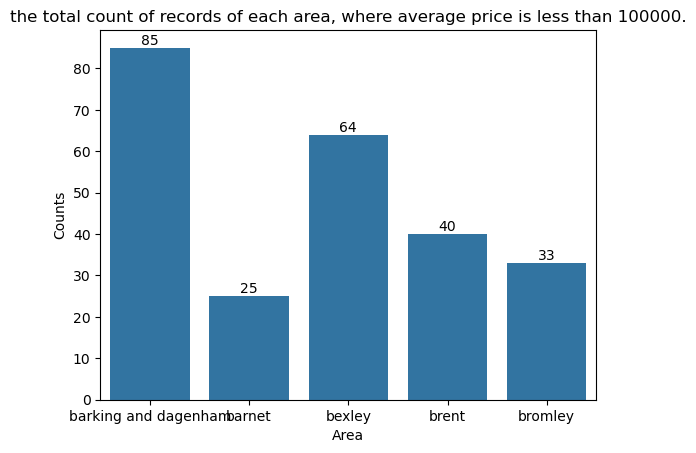

In [96]:
plots = df[df.average_price < 100000].groupby('area').area.count().head()
plt.title('the total count of records of each area, where average price is less than 100000.')
plt.xlabel('Area')
plt.ylabel('Counts')
ax = sns.barplot(x = plots.index, y = plots.values)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()